## Volcanoplot

Differential expression analyses frequently require a volcanoplot showing significance against fold-changes in order to pick out regulated features. Importantly, a volcanoplot is not so much a standalone kind of plot but a collection of several basic plotting elements, combined into a visual "mini-analysis" to identify significantly regulated hits. `alphapepttools.pl.volcano` summarizes several basic building blocks to abstract the following functionalities:

- scatterplot
- adding lines to the scatterplot
- adding anchored labels to the scatterplot
- adding axis labels (this is debatable, maybe we could keep this external)
- adding a legend
- setting plot x/y limits

In [ ]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np

from alphapepttools.pl import Plots
from alphapepttools.pl.colors import BaseColors

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Generate a small example dataset

We generate a small example dataset meant to resemble a typical differential expression outcome. 

In [ ]:
# Set up reproducible random number generation
rng = np.random.default_rng(seed=42)

# example data, should be replaced by actual differential expression results from example file
testx = rng.normal(0, 1, 300)
testy = -np.cos(testx) + rng.normal(0, 0.2, 300)
testp = 10 ** -(testy - min(testy))
vp_data = pd.DataFrame(
    {
        "id": [f"P{10000 + i}" for i in range(300)],
        "gene": [f"gene_{i}" for i in range(300)],
        "log2fc": testx,
        "pval": testp,
        "neg_log10pval": -np.log10(testp),
    }
)
vp_data.index = vp_data["id"].astype(str)

# Simulate differential expression annotation
vp_data["diff_exp_status"] = vp_data["log2fc"].apply(
    lambda x: "upregulated" if x > 1 else ("downregulated" if x < -1 else "unchanged")
)

# Suppose the first 10 genes are proteins of interest
vp_data["label"] = "other"
vp_data.loc[vp_data.index[:10], "label"] = "POI"

## Basic volcanoplot

At its core, the `volcano()` function is a convenience wrapper around `scatter()`, with a special focus on layered data annotation. This is obvious when we can call the function with the bare minimum of parameters next to the basic scatterplot:

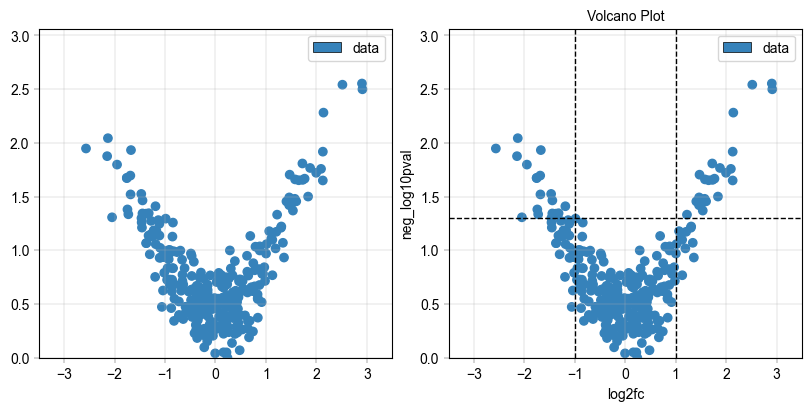

In [ ]:
from alphapepttools import pl

# As usual, we start with a figure and an axis manager that allows us to easily traverse subplots
fig, axm = pl.create_figure(1, 2, figsize=(8, 4))

# Scatterplot
Plots.scatter(
    ax=axm.next(),
    data=vp_data,
    x_column="log2fc",
    y_column="neg_log10pval",
    default_group="data",
    legend="auto",
)

# Volcanoplot, with some defaults for title, lines and labels
Plots.volcano(
    ax=axm.next(),
    data=vp_data,
    x_column="log2fc",
    y_column="neg_log10pval",
    default_group="data",
    legend="auto",
)

## Advanced layering in a volcanoplot

A particular consideration for volcanoplots is the differential coloring of various points of interest,
e.g. significantly regulated, manually selected or belonging to a certain group of interest. The current
solution uses `plot_layers` to define the hierarchy of visualization layers. `plot_layers` is a list of
tuples, where each tuple contains

layer_column, color_key, layer_val

- a `layer_column` from `data`
- a `color_key` to retrieve a color from the `color_dict`
- a `layer_val` to match in the `layer_column`, either a single value or a list of values

For example, given this plot_layers definition:

```
pois = ["P10291", "P10292", "P10293", "P10294", "P10295"]
plot_layers = [

    # look for all points in the "id" column that are in the pois list and color them according to the "POI_hypothesis" color in the color_dict
    ("id", "POI_hypothesis", pois), 

    # look for all points that have "POI" in the "label" column and color them according to the "POI" color in the color_dict
    ("label", "POI", "POI"), 

    # similar for regulation status
    ("diff_exp_status", "upregulated", "upregulated"),
    ("diff_exp_status", "downregulated", "downregulated"),
    ("diff_exp_status", "unchanged", "unchanged"),
]
```

Importantly, order matters: these plot_layers ensure that the 'pois' are on top, then the points labeled as 'POI', then the upregulated, downregulated and unchanged points in the background.

Combined with this layer_dict, we specify that we want to add labels to POI points and POI_hypothesis points.

```
label_layers = [
    "POI", # label all points where the label is "POI"
    "POI_hypothesis", # label all points in the pois list
]
```

in this configuration, every point is plotted exactly once in one layer, meaning there are no overplotting artefacts that sometimes show up in PNG/SVG renderings when multiple versions of a point with different colors are positioned on top of each other.

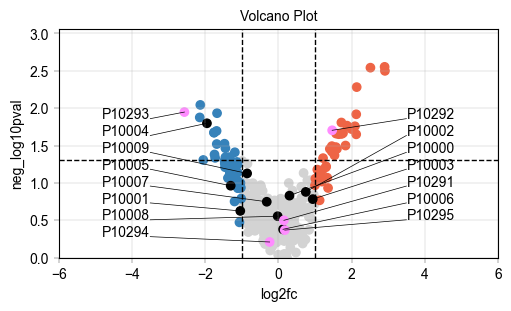

In [ ]:
# Select some points we want to highlight, e.g. if these had some hypothesis attached
pois = ["P10291", "P10292", "P10293", "P10294", "P10295"]

plot_layers = [
    ("id", "POI_hypothesis", pois),  # in the fifth layer, plot all points in pois list
    ("label", "POI", "POI"),  # in the fourth layer, plot all points where the label is "POI"
    ("diff_exp_status", "upregulated", "upregulated"),  # at the first layer
    ("diff_exp_status", "downregulated", "downregulated"),  # in the second layer
    ("diff_exp_status", "unchanged", "unchanged"),  # in the second layer
]

color_dict = {
    "upregulated": BaseColors.get("orange"),  # the specific point "P10001" should be colored orange
    "downregulated": BaseColors.get("blue"),  # the specific point "P10002" should be colored green
    "unchanged": BaseColors.get("grey"),  # points from the list ["P10002", "P10003", "P10004"] should be colored black
    "POI": "black",  # points where the label is "POI" should be colored red
    "POI_hypothesis": BaseColors.get("purple", lighten=0.7),  # points in the pois list should be colored purple
}

# Add labels to selected points
label_layers = [
    "POI",  # label all points where the label is "POI"
    "POI_hypothesis",  # label all points in the pois list
]


Plots.volcano(
    data=vp_data,
    x_column="log2fc",
    y_column="neg_log10pval",
    color_dict=color_dict,
    plot_layers=plot_layers,
    label_layers=label_layers,
    x_label_anchors=[-3.5, 3.5],
    y_padding_factor=1.7,
    y_display_start=0.75,
    xlims=(-6, 6),
    figure_kwargs={"figsize": (5, 3)},
)